In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, ConfusionMatrixDisplay)

In [31]:
df = pd.read_csv('/content/ABA FINAL MPI DATASET.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (36, 21)


,State,Region,MPI_Value,Headcount_Ratio_H,Intensity_A,Nutrition_Deprived,Child_Mortality_Deprived,Maternal_Health_Deprived,Years_of_Schooling_Deprived,School_Attendance_Deprived,...,Sanitation_Deprived,Drinking_Water_Deprived,Electricity_Deprived,Housing_Deprived,Assets_Deprived,Bank_Account_Deprived,Avg_Deprivation_Score,HDI_Proxy,Poverty_Risk_Category,Poverty_Risk_Label
0,Andhra Pradesh,South,0.068,14.01,48.6,27.3,1.8,9.2,18.4,6.3,...,14.2,3.1,5.8,20.1,15.3,8.4,13.2000,0.61,Medium,1
1,Arunachal Pradesh,Northeast,0.257,44.07,58.3,42.1,5.2,22.1,38.6,12.4,...,44.3,14.2,18.6,48.3,36.2,22.1,29.9417,0.48,High,2
2,Assam,Northeast,0.237,41.88,56.6,39.8,4.8,20.3,36.2,10.8,...,40.1,12.6,16.4,44.2,33.8,20.4,27.6500,0.50,High,2
3,Bihar,East,0.331,51.91,63.8,52.4,7.2,28.6,48.3,16.2,...,52.1,18.4,24.2,56.3,48.6,30.2,37.5750,0.44,High,2
4,Chhattisgarh,Central,0.272,45.47,59.8,44.2,5.8,24.2,40.8,13.6,...,46.2,15.8,20.4,50.6,38.4,24.6,31.9167,0.47,High,2


In [32]:
print("=" * 55)
print("        EXPLORATORY DATA ANALYSIS (EDA)")
print("=" * 55)

# 3.1 Shape & Columns
print(f"\n Rows    : {df.shape[0]}")
print(f" Columns : {df.shape[1]}")
print(f"\n Column Names:\n{df.columns.tolist()}")

# 3.2 Data Types
print(f"\n Data Types:\n{df.dtypes}")

# 3.3 Missing Values
print(f"\n Missing Values:\n{df.isnull().sum()}")

# 3.4 Statistical Summary
print(f"\n Statistical Summary:")
df.describe().round(3)

        EXPLORATORY DATA ANALYSIS (EDA)

 Rows    : 36
 Columns : 21

 Column Names:
['State', 'Region', 'MPI_Value', 'Headcount_Ratio_H', 'Intensity_A', 'Nutrition_Deprived', 'Child_Mortality_Deprived', 'Maternal_Health_Deprived', 'Years_of_Schooling_Deprived', 'School_Attendance_Deprived', 'Cooking_Fuel_Deprived', 'Sanitation_Deprived', 'Drinking_Water_Deprived', 'Electricity_Deprived', 'Housing_Deprived', 'Assets_Deprived', 'Bank_Account_Deprived', 'Avg_Deprivation_Score', 'HDI_Proxy', 'Poverty_Risk_Category', 'Poverty_Risk_Label']

 Data Types:
State                           object
Region                          object
MPI_Value                      float64
Headcount_Ratio_H              float64
Intensity_A                    float64
Nutrition_Deprived             float64
Child_Mortality_Deprived       float64
Maternal_Health_Deprived       float64
Years_of_Schooling_Deprived    float64
School_Attendance_Deprived     float64
Cooking_Fuel_Deprived          float64
Sanitation_Depri

,MPI_Value,Headcount_Ratio_H,Intensity_A,Nutrition_Deprived,Child_Mortality_Deprived,Maternal_Health_Deprived,Years_of_Schooling_Deprived,School_Attendance_Deprived,Cooking_Fuel_Deprived,Sanitation_Deprived,Drinking_Water_Deprived,Electricity_Deprived,Housing_Deprived,Assets_Deprived,Bank_Account_Deprived,Avg_Deprivation_Score,HDI_Proxy,Poverty_Risk_Label
count,36.000,36.000,36.000,36.000,36.000,36.000,36.000,36.000,36.000,36.000,36.000,36.000,36.000,36.000,36.000,36.000,36.000,36.000
mean,0.124,23.206,48.478,26.478,2.789,12.486,22.675,7.139,32.919,22.836,6.928,9.642,26.875,20.544,12.403,16.976,0.599,1.056
std,0.099,15.970,8.023,14.078,2.068,8.153,12.959,4.355,19.055,15.767,5.605,7.144,16.340,13.032,8.465,10.530,0.104,0.826
min,0.006,1.720,34.800,4.200,0.200,1.200,3.200,0.800,3.800,1.600,0.400,0.600,2.800,1.800,1.000,1.800,0.440,0.000
25%,0.040,9.170,42.700,12.800,0.875,5.100,12.100,3.325,16.300,9.650,2.200,3.350,14.150,10.000,5.500,8.000,0.520,0.000
50%,0.091,18.155,49.000,27.700,2.300,11.300,21.100,7.100,32.600,17.500,4.400,7.800,23.400,18.300,10.800,15.633,0.585,1.000
75%,0.192,37.272,52.550,38.300,4.450,19.300,32.500,9.850,48.600,36.750,11.450,15.300,40.950,30.600,18.650,25.558,0.700,2.000
max,0.331,51.910,63.800,52.400,7.200,28.600,48.300,16.200,68.400,52.100,18.400,24.200,56.300,48.600,30.200,37.575,0.780,2.000


In [33]:
print("=" * 55)
print("        DATA CLEANING VERIFICATION")
print("=" * 55)

# 4.1 Duplicate Check
print(f"\n Duplicate Rows : {df.duplicated().sum()}")

# 4.2 Outlier Detection using IQR Method
print("\n📐 Outlier Detection — IQR Method:")
print("-" * 55)

check_cols = ['MPI_Value', 'Headcount_Ratio_H',
              'Intensity_A', 'Avg_Deprivation_Score']

for col in check_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"\n{col}:")
    print(f"   Q1={Q1:.4f}  Q3={Q3:.4f}  IQR={IQR:.4f}")
    print(f"   Lower Bound = {lower:.4f}  |  Upper Bound = {upper:.4f}")
    print(f"   Outliers Found = {len(outliers)}")

print("\n No outliers found — dataset is clean!")

        DATA CLEANING VERIFICATION

 Duplicate Rows : 0

📐 Outlier Detection — IQR Method:
-------------------------------------------------------

MPI_Value:
   Q1=0.0395  Q3=0.1915  IQR=0.1520
   Lower Bound = -0.1885  |  Upper Bound = 0.4195
   Outliers Found = 0

Headcount_Ratio_H:
   Q1=9.1700  Q3=37.2725  IQR=28.1025
   Lower Bound = -32.9838  |  Upper Bound = 79.4263
   Outliers Found = 0

Intensity_A:
   Q1=42.7000  Q3=52.5500  IQR=9.8500
   Lower Bound = 27.9250  |  Upper Bound = 67.3250
   Outliers Found = 0

Avg_Deprivation_Score:
   Q1=8.0000  Q3=25.5583  IQR=17.5583
   Lower Bound = -18.3375  |  Upper Bound = 51.8958
   Outliers Found = 0

 No outliers found — dataset is clean!


In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [35]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [36]:
y_pred = model.predict(X_test)

In [37]:
print("\n  Poverty Risk Category Distribution:")
print(df['Poverty_Risk_Category'].value_counts())

print("\n Poverty Risk Label Distribution:")
print(df['Poverty_Risk_Label'].value_counts().sort_index())

print("\n  Region Distribution:")
print(df['Region'].value_counts())


  Poverty Risk Category Distribution:
Poverty_Risk_Category
High      13
Medium    12
Low       11
Name: count, dtype: int64

 Poverty Risk Label Distribution:
Poverty_Risk_Label
0    11
1    12
2    13
Name: count, dtype: int64

  Region Distribution:
Region
South        8
Northeast    8
North        7
West         5
Central      4
East         4
Name: count, dtype: int64


        VISUALIZATIONS


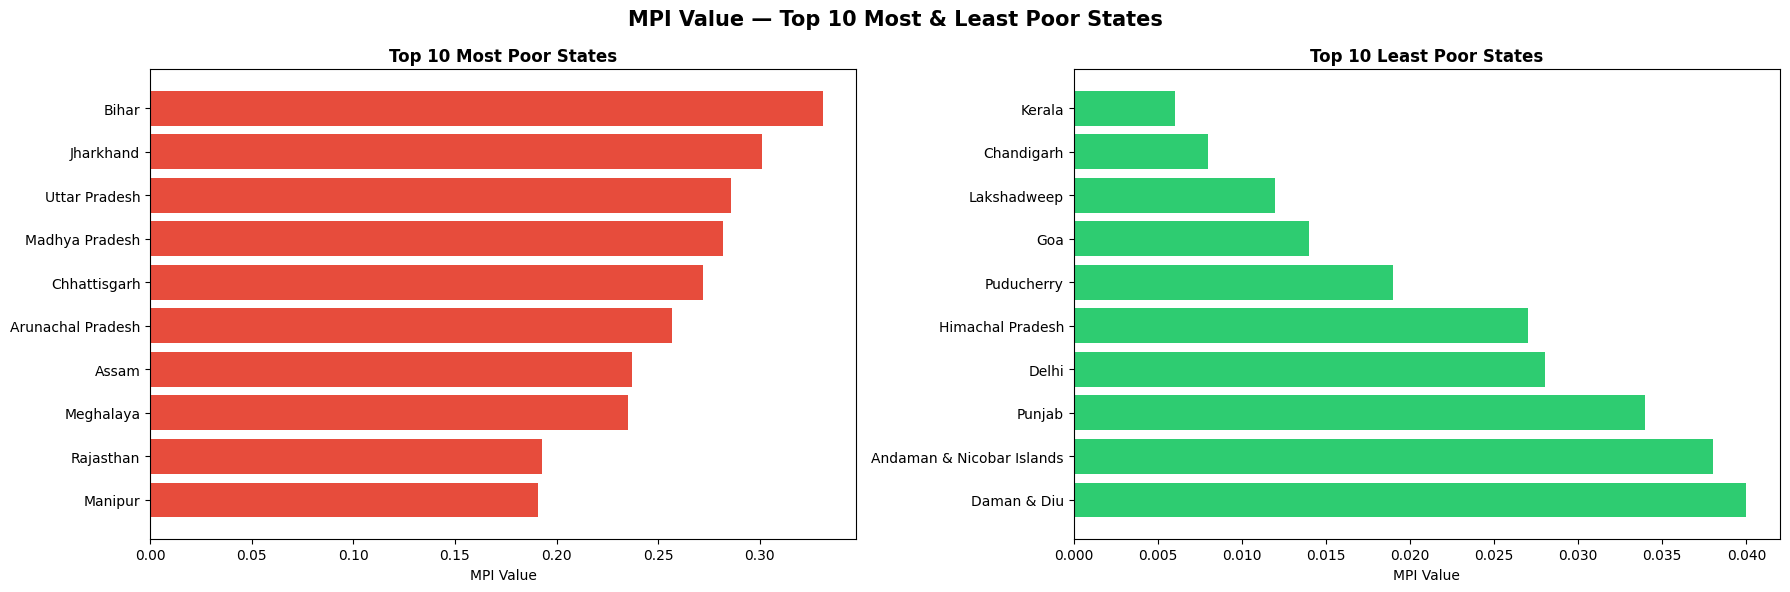

 Plot 1 saved!


In [38]:
print("=" * 55)
print("        VISUALIZATIONS")
print("=" * 55)

colors_cat = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}

# ── 5.1 Top 10 & Bottom 10 States by MPI Value
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('MPI Value — Top 10 Most & Least Poor States',
             fontsize=15, fontweight='bold')

top10 = df.nlargest(10, 'MPI_Value')
bot10 = df.nsmallest(10, 'MPI_Value')

axes[0].barh(top10['State'], top10['MPI_Value'], color='#e74c3c')
axes[0].set_title('Top 10 Most Poor States', fontweight='bold')
axes[0].set_xlabel('MPI Value')
axes[0].invert_yaxis()

axes[1].barh(bot10['State'], bot10['MPI_Value'], color='#2ecc71')
axes[1].set_title('Top 10 Least Poor States', fontweight='bold')
axes[1].set_xlabel('MPI Value')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('plot1_top_bottom_states.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Plot 1 saved!")

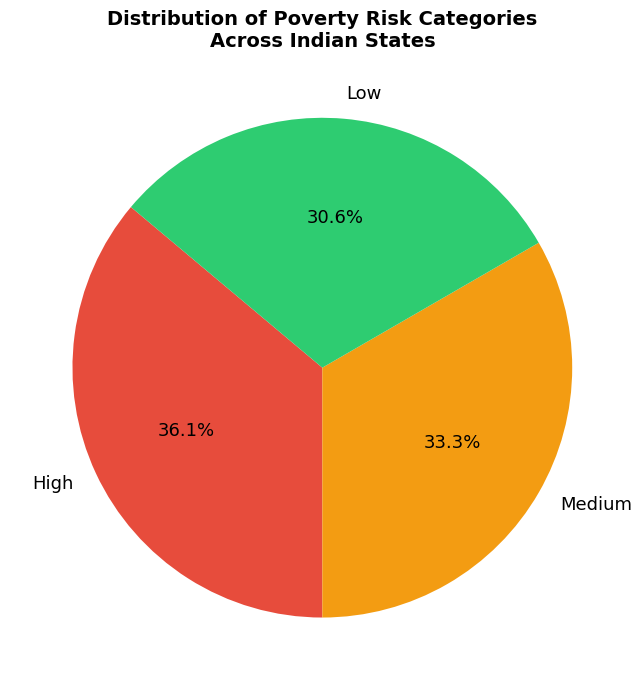

 Plot 2 saved!


In [39]:
fig, ax = plt.subplots(figsize=(7, 7))
counts = df['Poverty_Risk_Category'].value_counts()
ax.pie(counts, labels=counts.index, autopct='%1.1f%%',
       colors=[colors_cat[c] for c in counts.index],
       startangle=140, textprops={'fontsize': 13})
ax.set_title('Distribution of Poverty Risk Categories\nAcross Indian States',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot2_pie_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Plot 2 saved!")

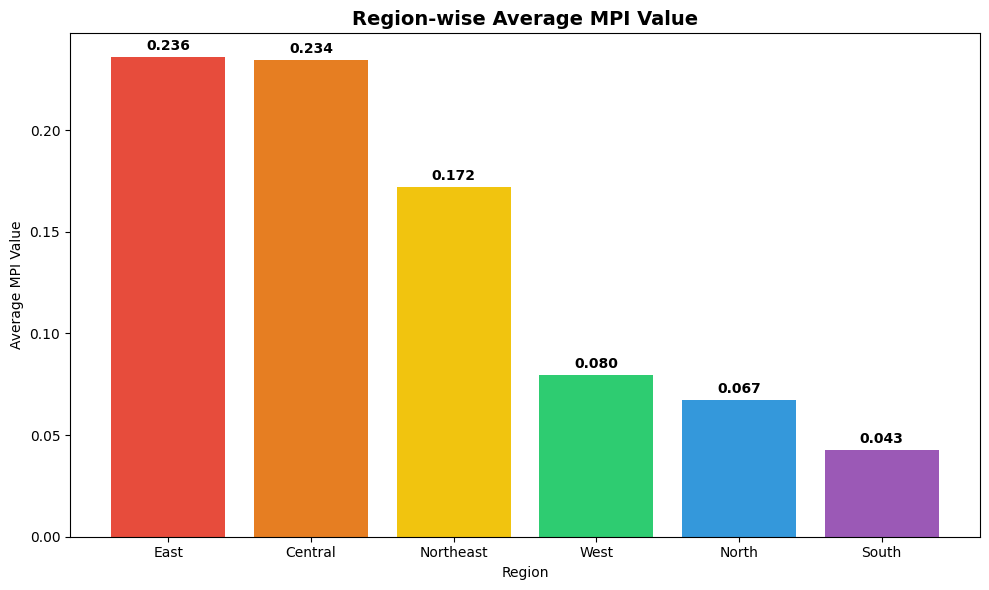

 Plot 3 saved!


In [40]:
fig, ax = plt.subplots(figsize=(10, 6))
region_mpi = df.groupby('Region')['MPI_Value'].mean().sort_values(ascending=False)
bars = ax.bar(region_mpi.index, region_mpi.values,
              color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db','#9b59b6'])
ax.set_title('Region-wise Average MPI Value', fontsize=14, fontweight='bold')
ax.set_xlabel('Region')
ax.set_ylabel('Average MPI Value')
for bar, val in zip(bars, region_mpi.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('plot3_region_mpi.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Plot 3 saved!")

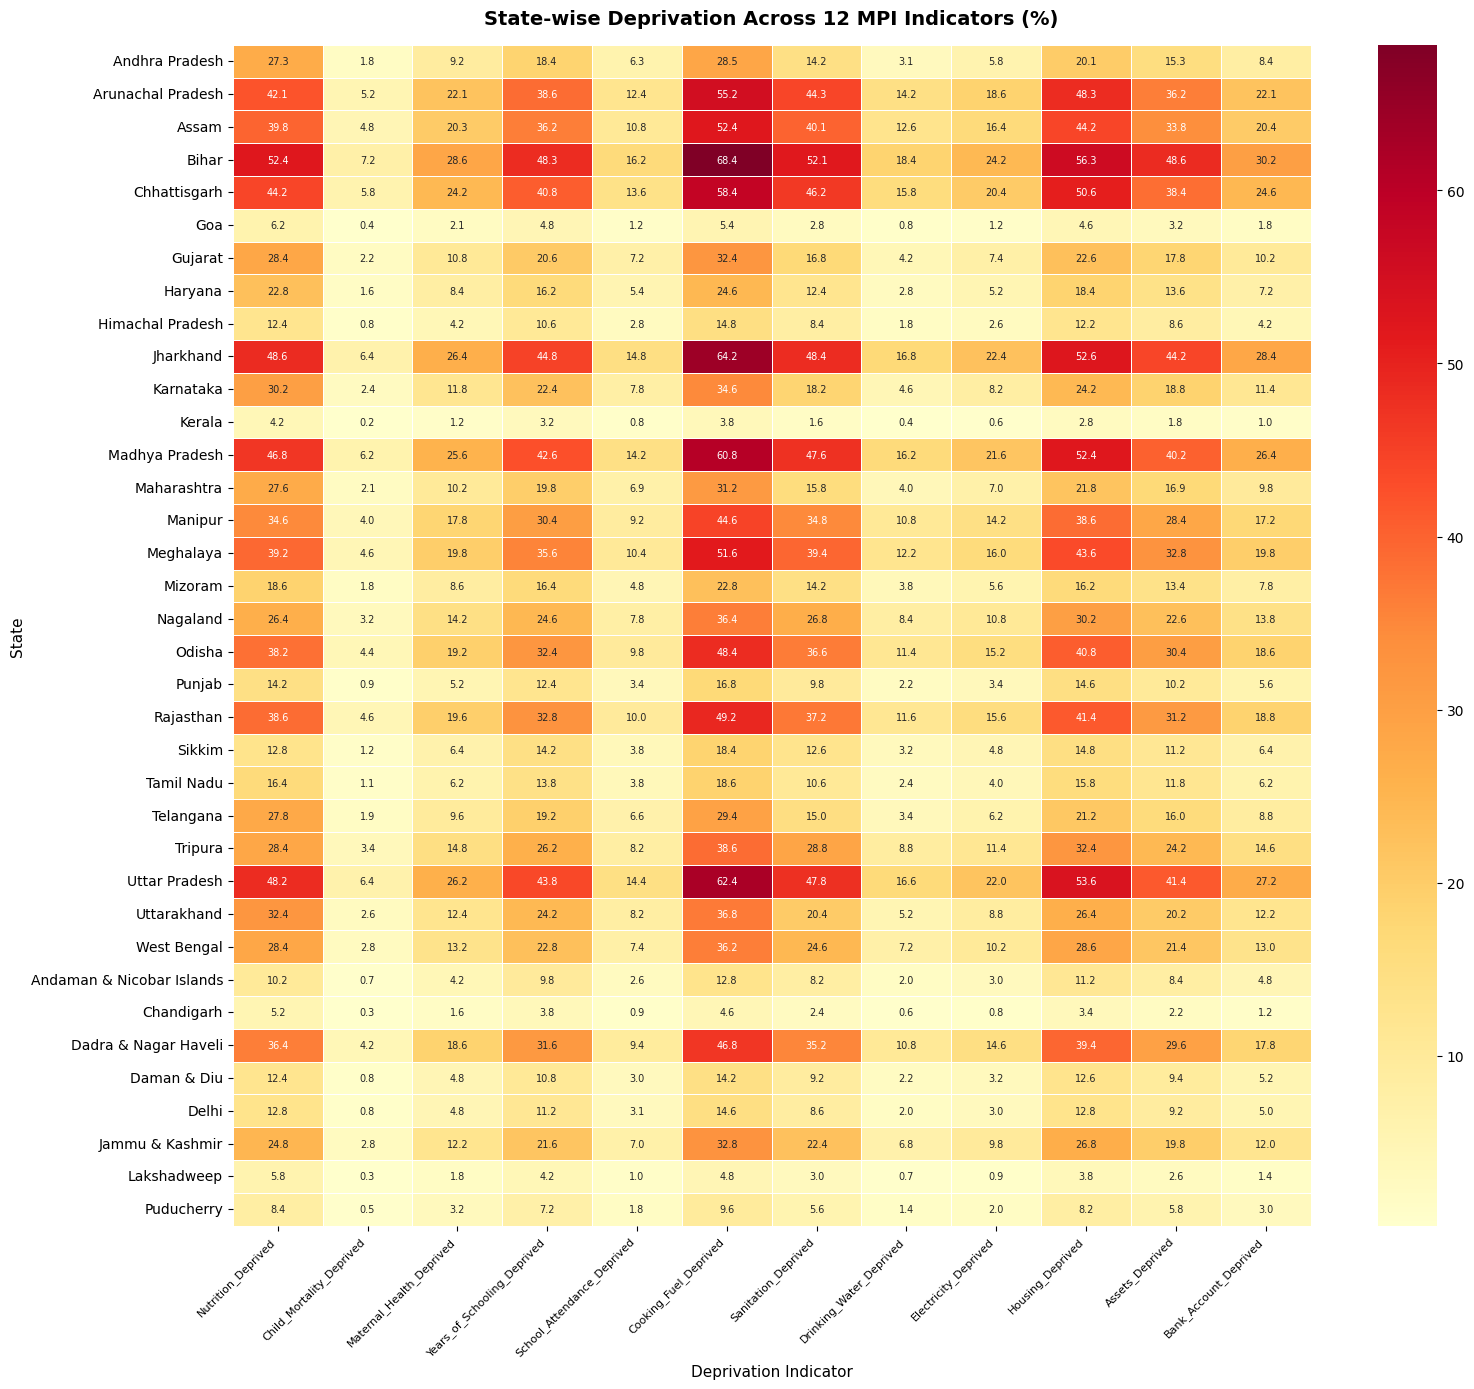

 Plot 4 saved!


In [41]:
indicator_cols = ['Nutrition_Deprived', 'Child_Mortality_Deprived',
                  'Maternal_Health_Deprived', 'Years_of_Schooling_Deprived',
                  'School_Attendance_Deprived', 'Cooking_Fuel_Deprived',
                  'Sanitation_Deprived', 'Drinking_Water_Deprived',
                  'Electricity_Deprived', 'Housing_Deprived',
                  'Assets_Deprived', 'Bank_Account_Deprived']

fig, ax = plt.subplots(figsize=(16, 14))
heat_data = df.set_index('State')[indicator_cols]
sns.heatmap(heat_data, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.4, ax=ax, annot_kws={'size': 7})
ax.set_title('State-wise Deprivation Across 12 MPI Indicators (%)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Deprivation Indicator', fontsize=11)
ax.set_ylabel('State', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('plot4_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Plot 4 saved!")

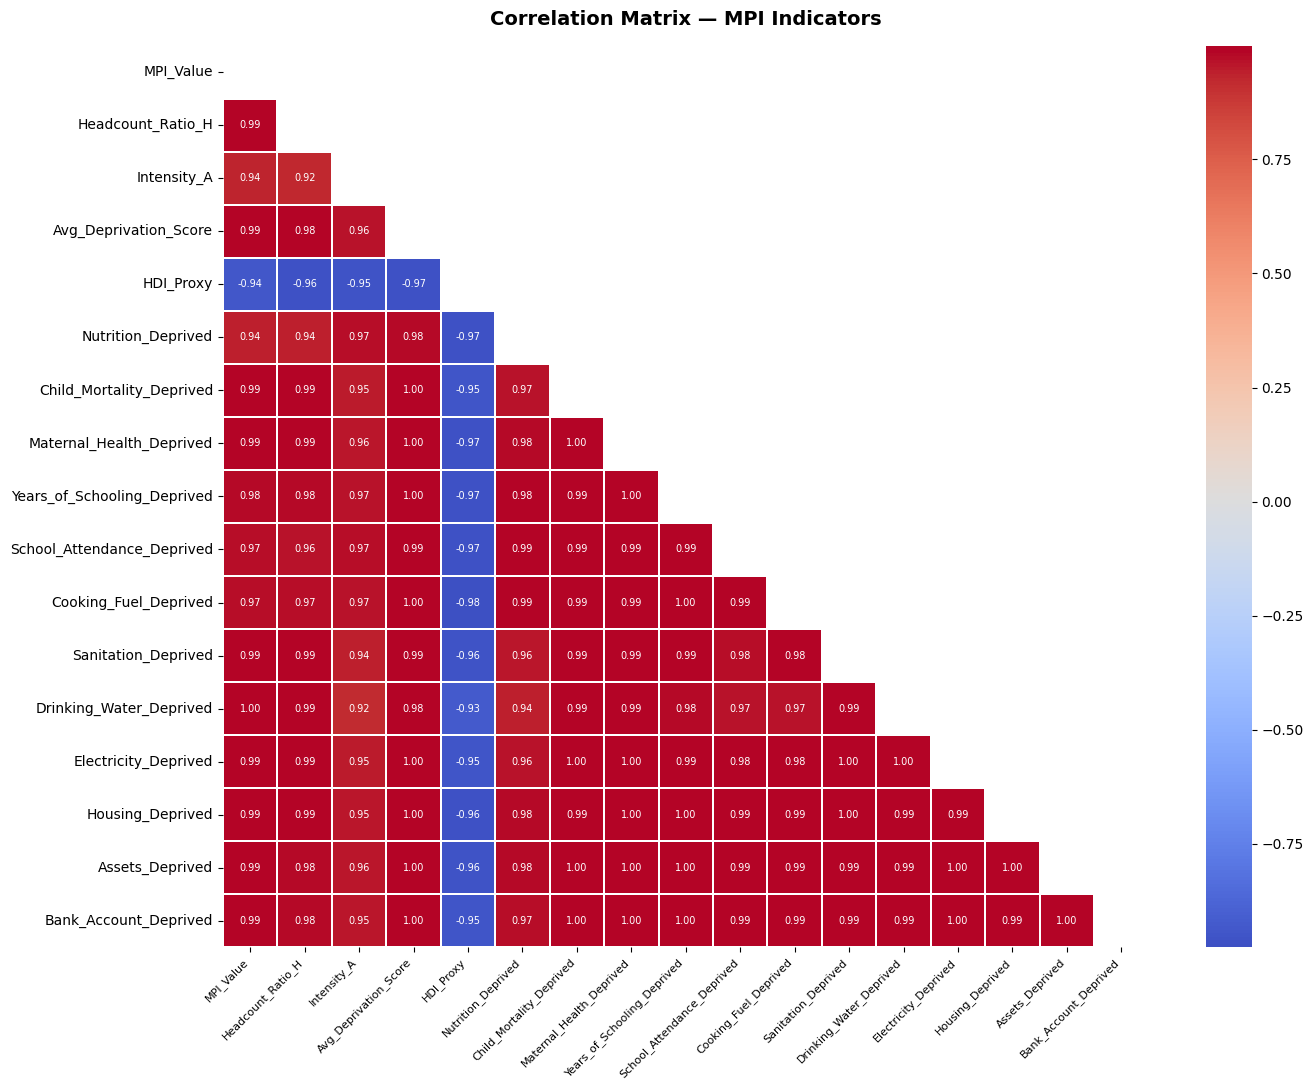

 Plot 5 saved!


In [42]:
fig, ax = plt.subplots(figsize=(14, 11))
corr_cols = ['MPI_Value', 'Headcount_Ratio_H', 'Intensity_A',
             'Avg_Deprivation_Score', 'HDI_Proxy'] + indicator_cols
corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax,
            annot_kws={'size': 7}, linewidths=0.3)
ax.set_title('Correlation Matrix — MPI Indicators',
             fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('plot5_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Plot 5 saved!")

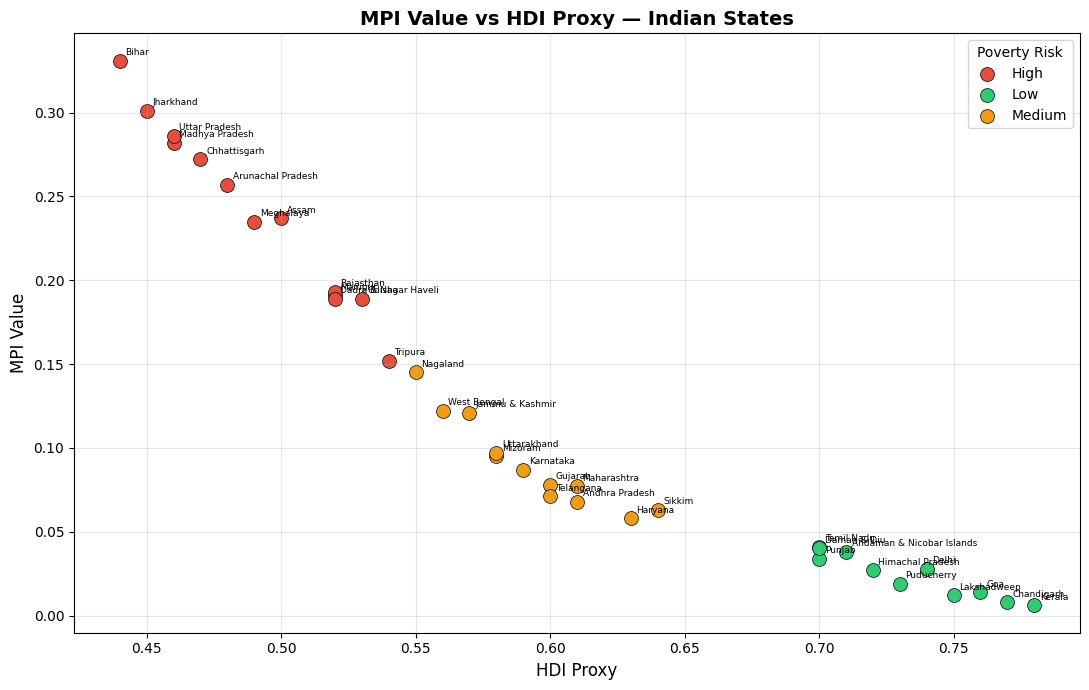

 Plot 6 saved!


In [43]:
fig, ax = plt.subplots(figsize=(11, 7))
for cat, grp in df.groupby('Poverty_Risk_Category'):
    ax.scatter(grp['HDI_Proxy'], grp['MPI_Value'],
               label=cat, color=colors_cat[cat], s=100, edgecolors='black', linewidth=0.5)
    for _, row in grp.iterrows():
        ax.annotate(row['State'], (row['HDI_Proxy'], row['MPI_Value']),
                    fontsize=6.5, xytext=(4, 4), textcoords='offset points')
ax.set_xlabel('HDI Proxy', fontsize=12)
ax.set_ylabel('MPI Value', fontsize=12)
ax.set_title('MPI Value vs HDI Proxy — Indian States', fontsize=14, fontweight='bold')
ax.legend(title='Poverty Risk', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plot6_scatter_mpi_hdi.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Plot 6 saved!")

        K-MEANS CLUSTERING
✅ Data scaled using StandardScaler


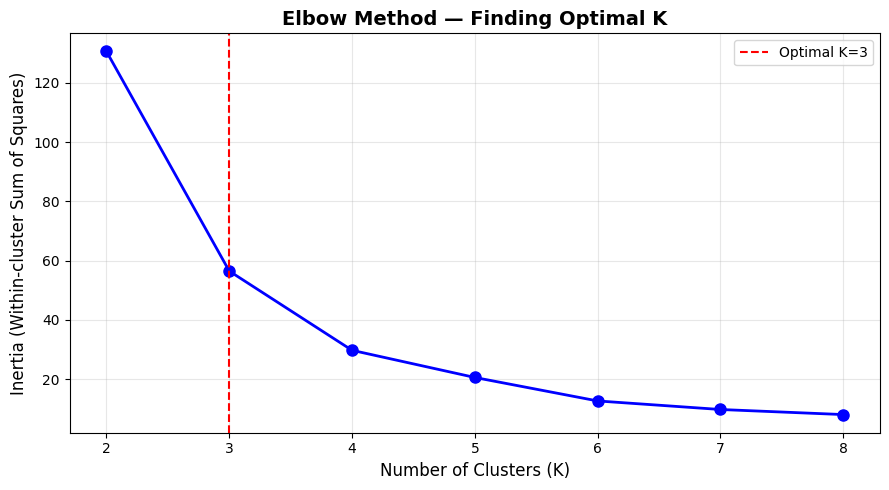

 Elbow plot saved! — Optimal K = 3


In [44]:
print("=" * 55)
print("        K-MEANS CLUSTERING")
print("=" * 55)

# 6.1 Prepare features for clustering
cluster_features = indicator_cols + ['MPI_Value', 'HDI_Proxy']
X_cluster = df[cluster_features].copy()

# 6.2 Scale the data (important for K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)
print("✅ Data scaled using StandardScaler")

# 6.3 Elbow Method — Find best K
inertia = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(K_range, inertia, 'bo-', linewidth=2, markersize=8)
ax.set_xlabel('Number of Clusters (K)', fontsize=12)
ax.set_ylabel('Inertia (Within-cluster Sum of Squares)', fontsize=12)
ax.set_title('Elbow Method — Finding Optimal K', fontsize=14, fontweight='bold')
ax.axvline(x=3, color='red', linestyle='--', label='Optimal K=3')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plot7_elbow.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Elbow plot saved! — Optimal K = 3")

In [45]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)
print(f"\n K-Means applied with K=3")
print(f"\nCluster Distribution:")
print(df['Cluster'].value_counts().sort_index())

# 6.5 Cluster Profiling
print("\n Cluster Profile — Average MPI Values:")
cluster_profile = df.groupby('Cluster')[['MPI_Value','Headcount_Ratio_H',
                                          'Intensity_A','HDI_Proxy',
                                          'Avg_Deprivation_Score']].mean().round(3)
print(cluster_profile)


 K-Means applied with K=3

Cluster Distribution:
Cluster
0    12
1    12
2    12
Name: count, dtype: int64

 Cluster Profile — Average MPI Values:
         MPI_Value  Headcount_Ratio_H  Intensity_A  HDI_Proxy  \
Cluster                                                         
0            0.028              6.701       39.542      0.725   
1            0.247             42.876       57.100      0.487   
2            0.098             20.042       48.792      0.585   

         Avg_Deprivation_Score  
Cluster                         
0                        5.738  
1                       29.678  
2                       15.513  



 Clusters labelled:
                        State  Cluster    Cluster_Name  MPI_Value
11                     Kerala        0     Low Poverty      0.006
29                 Chandigarh        0     Low Poverty      0.008
34                Lakshadweep        0     Low Poverty      0.012
5                         Goa        0     Low Poverty      0.014
35                 Puducherry        0     Low Poverty      0.019
8            Himachal Pradesh        0     Low Poverty      0.027
32                      Delhi        0     Low Poverty      0.028
19                     Punjab        0     Low Poverty      0.034
28  Andaman & Nicobar Islands        0     Low Poverty      0.038
31                Daman & Diu        0     Low Poverty      0.040
22                 Tamil Nadu        0     Low Poverty      0.041
7                     Haryana        2  Medium Poverty      0.058
21                     Sikkim        0     Low Poverty      0.063
0              Andhra Pradesh        2  Medium Poverty 

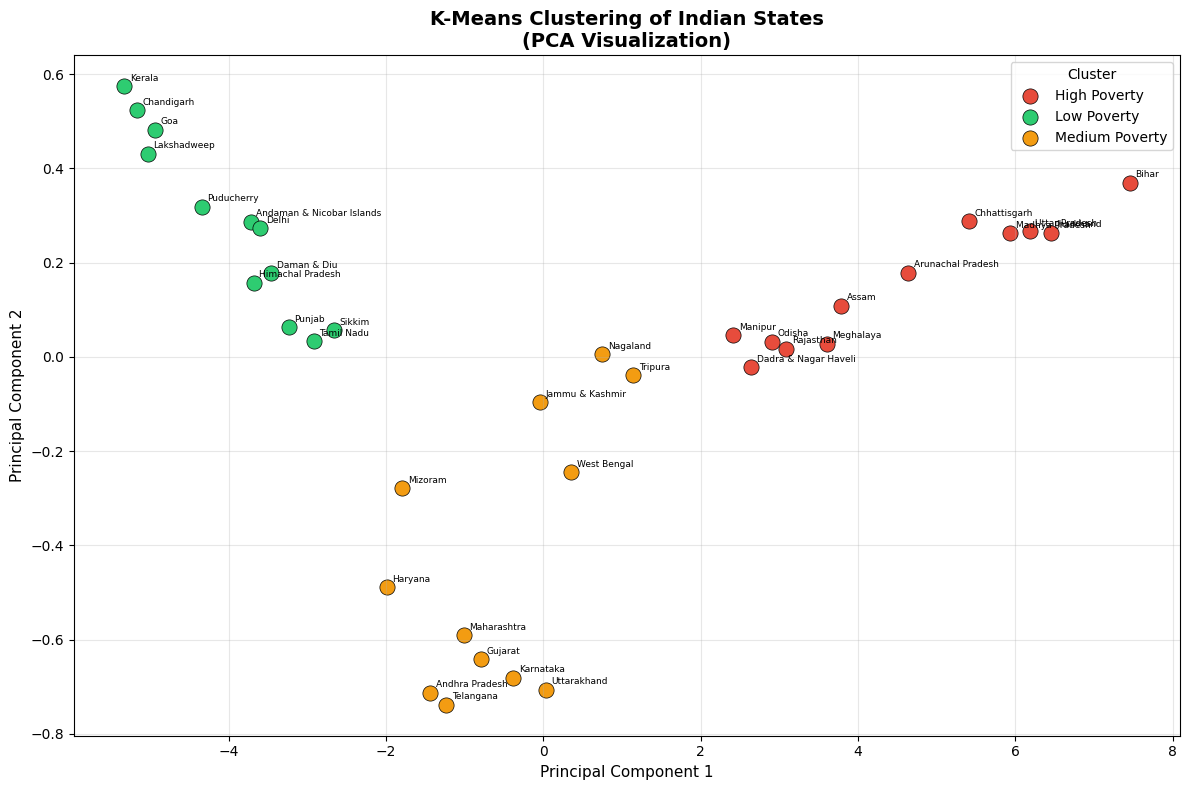

 Cluster PCA plot saved!


In [46]:
cluster_label_map = {}
cluster_mpi_means = df.groupby('Cluster')['MPI_Value'].mean().sort_values()
labels = ['Low Poverty', 'Medium Poverty', 'High Poverty']
for i, (cluster_id, _) in enumerate(cluster_mpi_means.items()):
    cluster_label_map[cluster_id] = labels[i]

df['Cluster_Name'] = df['Cluster'].map(cluster_label_map)
print(f"\n Clusters labelled:")
print(df[['State', 'Cluster', 'Cluster_Name', 'MPI_Value']].sort_values('MPI_Value'))

# 6.7 PCA Visualization of Clusters
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X_scaled)
df['PCA1'] = pca_coords[:, 0]
df['PCA2'] = pca_coords[:, 1]

cluster_colors = {'Low Poverty': '#2ecc71',
                  'Medium Poverty': '#f39c12',
                  'High Poverty': '#e74c3c'}

fig, ax = plt.subplots(figsize=(12, 8))
for name, grp in df.groupby('Cluster_Name'):
    ax.scatter(grp['PCA1'], grp['PCA2'], label=name,
               color=cluster_colors[name], s=120,
               edgecolors='black', linewidth=0.5)
    for _, row in grp.iterrows():
        ax.annotate(row['State'], (row['PCA1'], row['PCA2']),
                    fontsize=6.5, xytext=(4, 4), textcoords='offset points')
ax.set_xlabel('Principal Component 1', fontsize=11)
ax.set_ylabel('Principal Component 2', fontsize=11)
ax.set_title('K-Means Clustering of Indian States\n(PCA Visualization)',
             fontsize=14, fontweight='bold')
ax.legend(title='Cluster', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plot8_kmeans_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Cluster PCA plot saved!")

In [47]:
print("=" * 55)
print("        RANDOM FOREST CLASSIFICATION")
print("=" * 55)

# 7.1 Prepare Features & Target
features = indicator_cols + ['MPI_Value', 'Headcount_Ratio_H',
                              'Intensity_A', 'HDI_Proxy',
                              'Avg_Deprivation_Score']
X = df[features]
y = df['Poverty_Risk_Label']

print(f" Features used : {len(features)}")
print(f" Target        : Poverty_Risk_Label (0=Low, 1=Medium, 2=High)")

# 7.2 Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\n Train size : {X_train.shape[0]} rows")
print(f" Test size  : {X_test.shape[0]} rows")


        RANDOM FOREST CLASSIFICATION
 Features used : 17
 Target        : Poverty_Risk_Label (0=Low, 1=Medium, 2=High)

 Train size : 28 rows
 Test size  : 8 rows


In [48]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    class_weight='balanced'
)
rf_model.fit(X_train, y_train)
print("\n Random Forest model trained!")

# 7.4 Predictions & Accuracy
y_pred = rf_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"\n Model Accuracy : {acc * 100:.2f}%")



 Random Forest model trained!

 Model Accuracy : 87.50%



📋 Classification Report:
              precision    recall  f1-score   support

         Low       0.67      1.00      0.80         2
      Medium       1.00      0.67      0.80         3
        High       1.00      1.00      1.00         3

    accuracy                           0.88         8
   macro avg       0.89      0.89      0.87         8
weighted avg       0.92      0.88      0.88         8



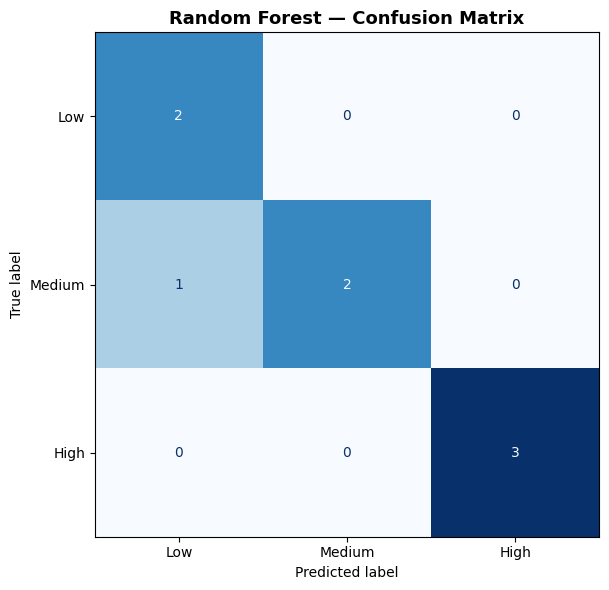

 Confusion Matrix saved!


In [49]:
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Low', 'Medium', 'High']))

# 7.6 Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Low', 'Medium', 'High'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Random Forest — Confusion Matrix',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot9_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Confusion Matrix saved!")

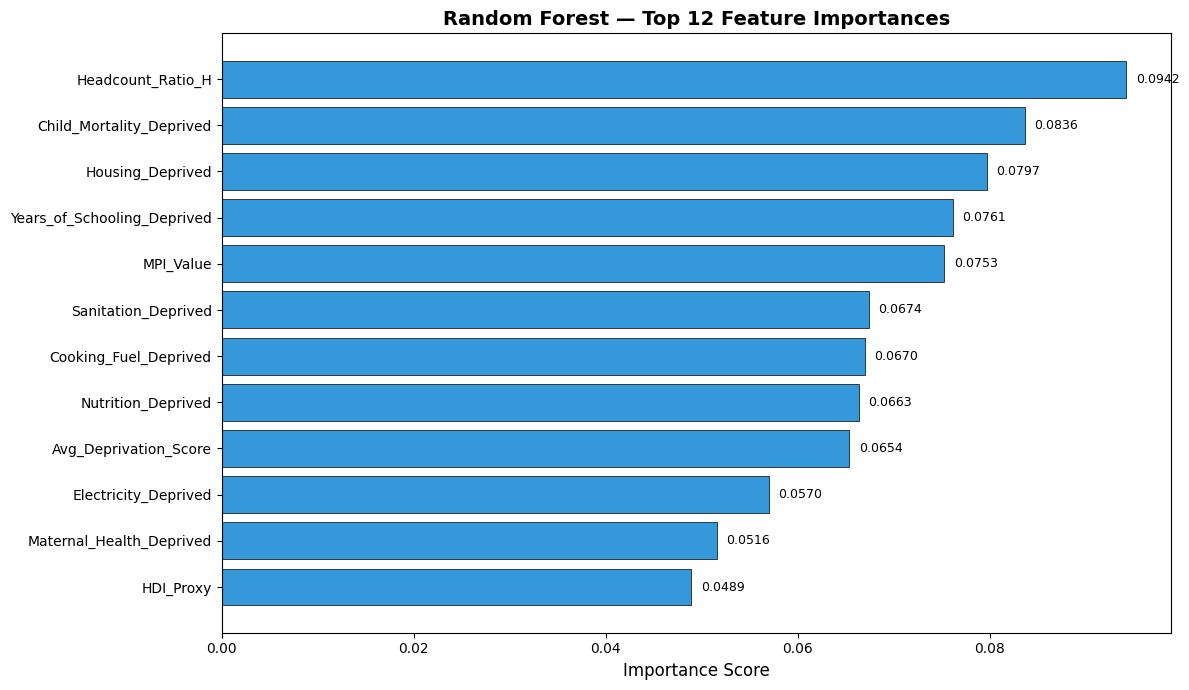

 Feature Importance plot saved!

🥇 Most Important Feature : Headcount_Ratio_H
🥈 2nd Most Important     : Child_Mortality_Deprived
🥉 3rd Most Important     : Housing_Deprived


In [50]:
importances = pd.Series(rf_model.feature_importances_, index=features)
importances_sorted = importances.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(importances_sorted.index[:12],
               importances_sorted.values[:12],
               color='#3498db', edgecolor='black', linewidth=0.5)
ax.set_title('Random Forest — Top 12 Feature Importances',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=12)
ax.invert_yaxis()
for bar, val in zip(bars, importances_sorted.values[:12]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('plot10_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Feature Importance plot saved!")

print(f"\n🥇 Most Important Feature : {importances_sorted.index[0]}")
print(f"🥈 2nd Most Important     : {importances_sorted.index[1]}")
print(f"🥉 3rd Most Important     : {importances_sorted.index[2]}")

In [51]:
print("\n" + "=" * 55)
print("           FINAL PROJECT SUMMARY")
print("=" * 55)

print(f"""
📌 Dataset       : NITI Aayog National MPI 2023
📌 States        : 36 States & Union Territories
📌 Features      : 17 (12 indicators + MPI metrics + HDI)
📌 Target        : Poverty Risk Category (Low/Medium/High)

🤖 MODELS USED:
   ├── K-Means Clustering  (K=3)
   └── Random Forest       (100 trees)

📊 RESULTS:
   ├── Random Forest Accuracy : {acc * 100:.2f}%
   ├── Most Deprived State    : {df.loc[df['MPI_Value'].idxmax(), 'State']}
   ├── Least Deprived State   : {df.loc[df['MPI_Value'].idxmin(), 'State']}
   └── Key Poverty Driver     : {importances_sorted.index[0]}

✅ All 10 plots saved as PNG files!
""")


           FINAL PROJECT SUMMARY

📌 Dataset       : NITI Aayog National MPI 2023
📌 States        : 36 States & Union Territories
📌 Features      : 17 (12 indicators + MPI metrics + HDI)
📌 Target        : Poverty Risk Category (Low/Medium/High)
 
🤖 MODELS USED:
   ├── K-Means Clustering  (K=3)
   └── Random Forest       (100 trees)
 
📊 RESULTS:
   ├── Random Forest Accuracy : 87.50%
   ├── Most Deprived State    : Bihar
   ├── Least Deprived State   : Kerala
   └── Key Poverty Driver     : Headcount_Ratio_H
 
✅ All 10 plots saved as PNG files!

